In [4]:
"""
=============================================================
 Regression Analysis Tutorial - California Housing Dataset
=============================================================
 STEP 1. Load Data  (local CSV)
 STEP 2. Simple Linear Regression    (MedInc only)
 STEP 3. Multiple Linear Regression  (all 8 features)
 STEP 4. ML Regression Models        (RF / GBM / SVR)
 STEP 5. Error Metrics               (MSE, RMSE, MAE, R2, MAPE)
 STEP 6. Residual Analysis & Visualization
=============================================================
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm
import duckdb

def esql(query):
    return duckdb.sql(query).df()

pd.set_option("display.expand_frame_repr", False) 

# ── Color palette ──────────────────────────────────────────
COLORS = {
    'Simple LR'         : '#4C72B0',
    'Multiple LR'       : '#DD8452',
    'Random Forest'     : '#55A868',
    'Gradient Boosting' : '#C44E52',
    'SVR'               : '#8172B2',
}
C = list(COLORS.values())

In [3]:
# =============================================================
# STEP 1. Load Data
# =============================================================
print("=" * 60)
print("STEP 1. Load Data")
print("=" * 60)

feature_names = [
    'MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
    'Population', 'AveOccup', 'Latitude', 'Longitude'
]
df = pd.read_csv("california_housing.csv")
print(df.head())

print(f"Shape  : {df.shape}")
print(f"Features : {feature_names}")
print(f"\nDescribe:\n{df.describe().round(3)}")
print(f"\nMissing values:\n{df.isna().sum()}")

# Train / Test split
X = df[feature_names]
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling for ML models
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"\nTrain set : {X_train.shape}")
print(f"Test  set : {X_test.shape}")

STEP 1. Load Data
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  Longitude  MedHouseVal
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88    -122.23        4.526
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86    -122.22        3.585
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85    -122.24        3.521
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85    -122.25        3.413
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85    -122.25        3.422
Shape  : (20640, 9)
Features : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Describe:
          MedInc   HouseAge   AveRooms  AveBedrms  Population   AveOccup   Latitude  Longitude  MedHouseVal
count  20640.000  20640.000  20640.000  20640.000   20640.000  20640.000  20640.000  20640.000    20640.000
mean       3.871     28.639      5.429     

In [12]:
print(esql("select avg(medinc) from X_train"))
print(esql("select avg(medinc) from X_test"))
print(y_train.mean())
print(y_test.mean())

   avg(medinc)
0     3.880754
   avg(medinc)
0     3.830338
2.071946937378876
2.0550030959302323


In [13]:
# =============================================================
# STEP 2. Simple Linear Regression  (single feature: MedInc)
# =============================================================
print("\n" + "=" * 60)
print("STEP 2. Simple Linear Regression  (feature: MedInc only)")
print("=" * 60)

simple_lr = LinearRegression()
simple_lr.fit(X_train[['MedInc']], y_train)
y_pred_simple = simple_lr.predict(X_test[['MedInc']])

print(f"Coefficient (slope) : {simple_lr.coef_[0]:.4f}")
print(f"Intercept           : {simple_lr.intercept_:.4f}")
print(f"Equation            : y = {simple_lr.coef_[0]:.4f} * MedInc + {simple_lr.intercept_:.4f}")


STEP 2. Simple Linear Regression  (feature: MedInc only)
Coefficient (slope) : 0.4193
Intercept           : 0.4446
Equation            : y = 0.4193 * MedInc + 0.4446


In [14]:
# =============================================================
# STEP 2-1. Simple LR Statistical Summary (p-value 포함)
# =============================================================
print("\n" + "=" * 60)
print("STEP 2-1. OLS Statistical Summary (MedInc only)")
print("=" * 60)

X_train_sm = sm.add_constant(X_train[['MedInc']])
ols_simple = sm.OLS(y_train, X_train_sm).fit()

print(ols_simple.summary())

summary_table = pd.DataFrame({
    'coef': ols_simple.params,
    'std err': ols_simple.bse,
    't': ols_simple.tvalues,
    'p>|t|': ols_simple.pvalues,
    '[0.025': ols_simple.conf_int()[0],
    '0.975]': ols_simple.conf_int()[1],
})

print("\n[핵심 계수 통계]")
print(summary_table.round(6).to_string())
print(f"\nModel F-statistic p-value : {ols_simple.f_pvalue:.6g}")


STEP 2-1. OLS Statistical Summary (MedInc only)
                            OLS Regression Results                            
Dep. Variable:            MedHouseVal   R-squared:                       0.477
Model:                            OLS   Adj. R-squared:                  0.477
Method:                 Least Squares   F-statistic:                 1.506e+04
Date:                Mon, 06 Apr 2026   Prob (F-statistic):               0.00
Time:                        03:53:46   Log-Likelihood:                -20475.
No. Observations:               16512   AIC:                         4.095e+04
Df Residuals:                   16510   BIC:                         4.097e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
con

In [15]:
# =============================================================
# STEP 3. Multiple Linear Regression  (all 8 features)
# =============================================================
print("\n" + "=" * 60)
print("STEP 3. Multiple Linear Regression  (all 8 features)")
print("=" * 60)

multi_lr = LinearRegression()
multi_lr.fit(X_train, y_train)
y_pred_multi = multi_lr.predict(X_test)

coef_df = pd.DataFrame({
    'Feature'    : housing.feature_names,
    'Coefficient': multi_lr.coef_
}).sort_values('Coefficient', ascending=False)

print(f"\nCoefficients:\n{coef_df.to_string(index=False)}")
print(f"\nIntercept: {multi_lr.intercept_:.4f}")
print("Note: positive = price-up factor / negative = price-down factor")


STEP 3. Multiple Linear Regression  (all 8 features)

Coefficients:
   Feature  Coefficient
 AveBedrms     0.783145
    MedInc     0.448675
  HouseAge     0.009724
Population    -0.000002
  AveOccup    -0.003526
  AveRooms    -0.123323
  Latitude    -0.419792
 Longitude    -0.433708

Intercept: -37.0233
Note: positive = price-up factor / negative = price-down factor


In [16]:
# =============================================================
# STEP 3-1. Multiple LR OLS Statistical Summary (p-value 포함)
# =============================================================
print("\n" + "=" * 60)
print("STEP 3-1. OLS Statistical Summary (all 8 features)")
print("=" * 60)

X_train_multi_sm = sm.add_constant(X_train)
ols_multi = sm.OLS(y_train, X_train_multi_sm).fit()

print(ols_multi.summary())

multi_summary_table = pd.DataFrame({
    'coef': ols_multi.params,
    'std err': ols_multi.bse,
    't': ols_multi.tvalues,
    'p>|t|': ols_multi.pvalues,
    '[0.025': ols_multi.conf_int()[0],
    '0.975]': ols_multi.conf_int()[1],
}).sort_values('p>|t|')

print("\n[핵심 계수 통계 - p-value 오름차순]")
print(multi_summary_table.round(6).to_string())
print(f"\nModel F-statistic p-value : {ols_multi.f_pvalue:.6g}")


STEP 3-1. OLS Statistical Summary (all 8 features)
                            OLS Regression Results                            
Dep. Variable:            MedHouseVal   R-squared:                       0.613
Model:                            OLS   Adj. R-squared:                  0.612
Method:                 Least Squares   F-statistic:                     3261.
Date:                Mon, 06 Apr 2026   Prob (F-statistic):               0.00
Time:                        03:56:42   Log-Likelihood:                -17998.
No. Observations:               16512   AIC:                         3.601e+04
Df Residuals:                   16503   BIC:                         3.608e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------


In [17]:
# =============================================================
# STEP 4. ML Regression Models
# =============================================================
print("\n" + "=" * 60)
print("STEP 4. ML Regression Models")
print("=" * 60)

rf  = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
gb  = GradientBoostingRegressor(n_estimators=100, random_state=42)
svr = SVR(kernel='rbf', C=10, gamma=0.1)

rf.fit(X_train_sc, y_train);   print("Random Forest     -- done")
gb.fit(X_train_sc, y_train);   print("Gradient Boosting -- done")
svr.fit(X_train_sc, y_train);  print("SVR               -- done")

y_preds = {
    'Simple LR'         : y_pred_simple,
    'Multiple LR'       : y_pred_multi,
    'Random Forest'     : rf.predict(X_test_sc),
    'Gradient Boosting' : gb.predict(X_test_sc),
    'SVR'               : svr.predict(X_test_sc),
}



STEP 4. ML Regression Models
Random Forest     -- done
Gradient Boosting -- done
SVR               -- done


In [18]:
pred_df = pd.DataFrame(y_preds).reset_index(drop=True)
y_test_df = y_test.reset_index(drop=True).rename("y_test")

result_df = pd.concat([pred_df, y_test_df], axis=1)
result_df.head()

,Simple LR,Multiple LR,Random Forest,Gradient Boosting,SVR,y_test
0,1.149589,0.719123,0.509500,0.505188,0.491955,0.47700
1,1.506069,1.764017,0.741610,1.093346,1.462017,0.45800
2,1.903937,2.709659,4.923257,4.245710,4.161165,5.00001
3,2.850594,2.838926,2.529610,2.545174,2.433962,2.18600
4,2.006633,2.604657,2.273690,2.279103,2.726704,2.78000


In [19]:
# =============================================================
# STEP 5. Error Metrics
# =============================================================
print("\n" + "=" * 60)
print("STEP 5. Error Metrics Comparison")
print("=" * 60)

def evaluate(y_true, y_pred, name):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mask = y_true.values != 0
    mape = np.mean(np.abs((y_true.values[mask] - y_pred[mask])
                           / y_true.values[mask])) * 100
    return {'Model': name, 'MSE': mse, 'RMSE': rmse,
            'MAE': mae, 'R2': r2, 'MAPE(%)': mape}

results   = [evaluate(y_test, yp, nm) for nm, yp in y_preds.items()]
result_df = pd.DataFrame(results).set_index('Model')
print(result_df.round(4).to_string())

print("\n[Metric Guide]")
print("  MSE     : Mean Squared Error        -- penalizes large errors heavily")
print("  RMSE    : Root MSE                  -- same unit as target ($100K)")
print("  MAE     : Mean Absolute Error       -- robust to outliers")
print("  R2      : Coefficient of Determination -- 1.0 = perfect fit")
print("  MAPE(%) : Mean Absolute % Error     -- scale-independent, intuitive")


STEP 5. Error Metrics Comparison
                      MSE    RMSE     MAE      R2  MAPE(%)
Model                                                     
Simple LR          0.7091  0.8421  0.6299  0.4589  39.0558
Multiple LR        0.5559  0.7456  0.5332  0.5758  31.9522
Random Forest      0.2552  0.5051  0.3274  0.8053  18.9090
Gradient Boosting  0.2940  0.5422  0.3717  0.7756  21.5266
SVR                0.3314  0.5757  0.3832  0.7471  20.8379

[Metric Guide]
  MSE     : Mean Squared Error        -- penalizes large errors heavily
  RMSE    : Root MSE                  -- same unit as target ($100K)
  MAE     : Mean Absolute Error       -- robust to outliers
  R2      : Coefficient of Determination -- 1.0 = perfect fit
  MAPE(%) : Mean Absolute % Error     -- scale-independent, intuitive



STEP 6. Visualization -- generating 6 figures


/Users/erickim/Documents/ML_Training/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


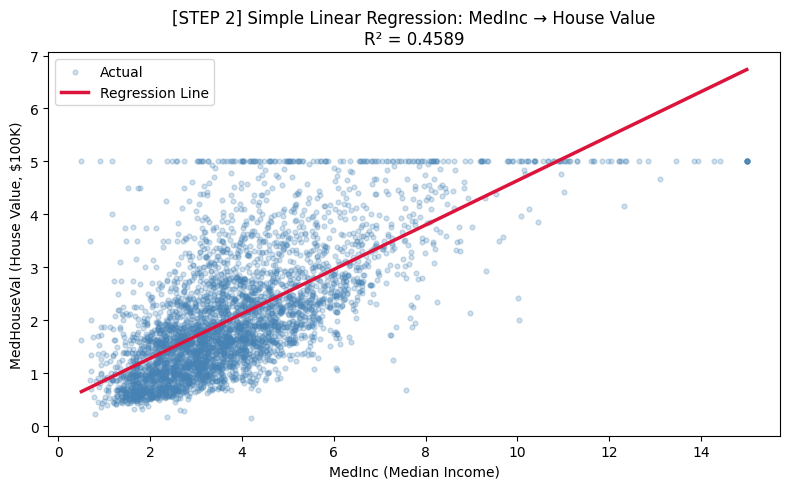

fig1 saved -- Simple Linear Regression


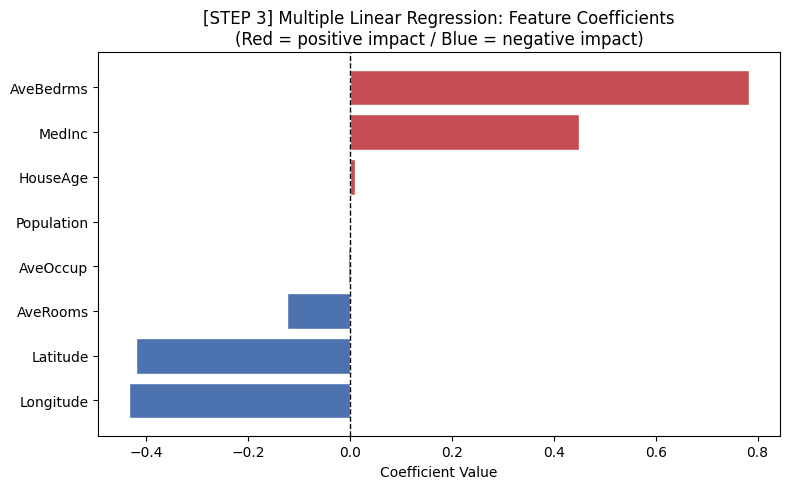

fig2 saved -- Multiple LR Coefficients


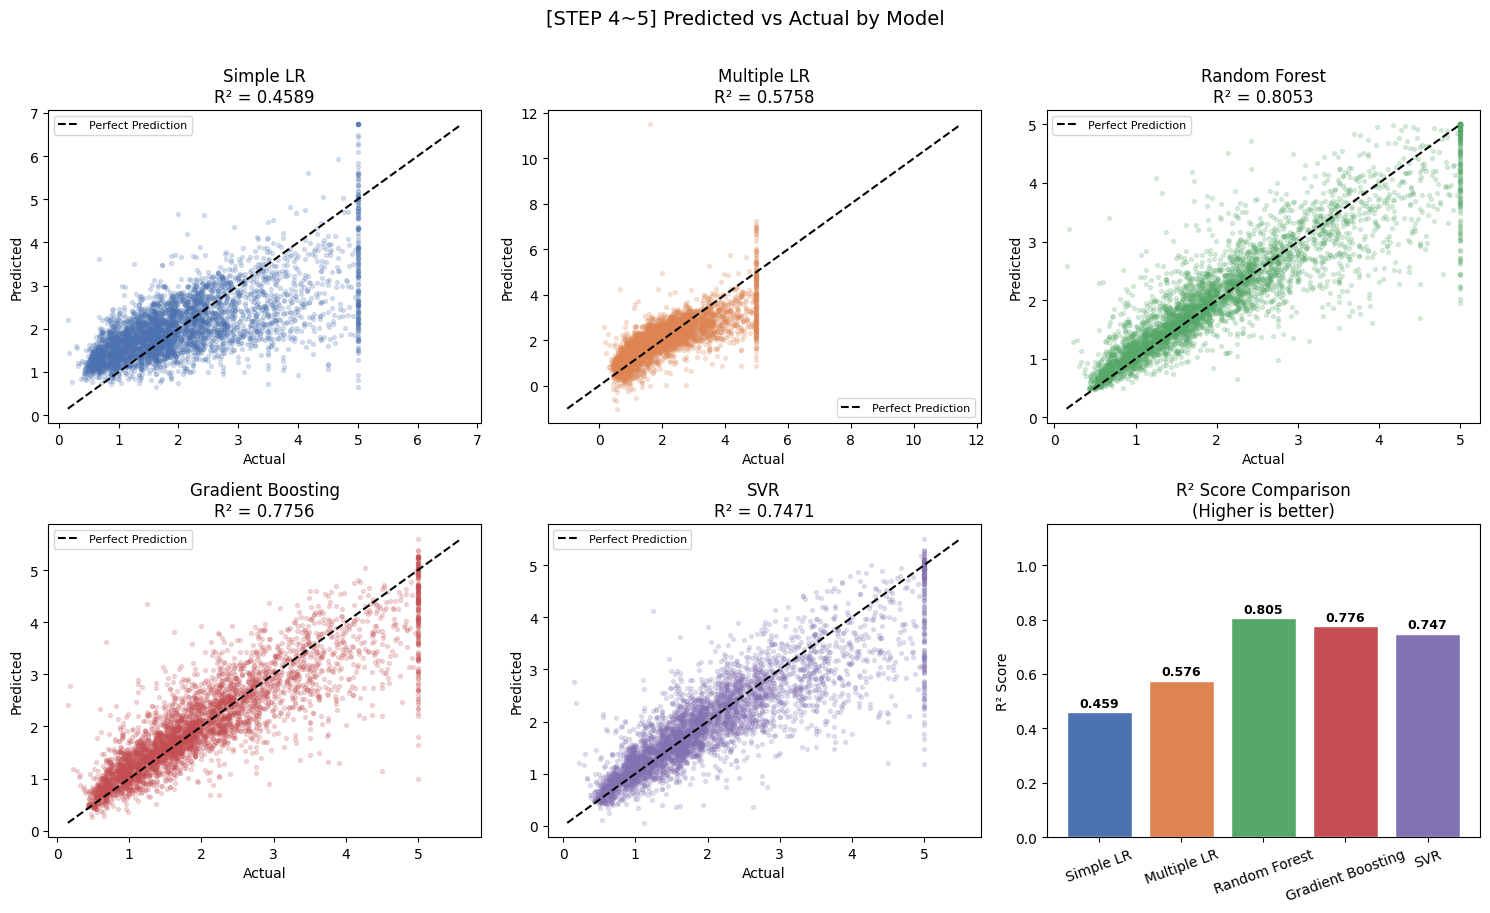

fig3 saved -- Predicted vs Actual


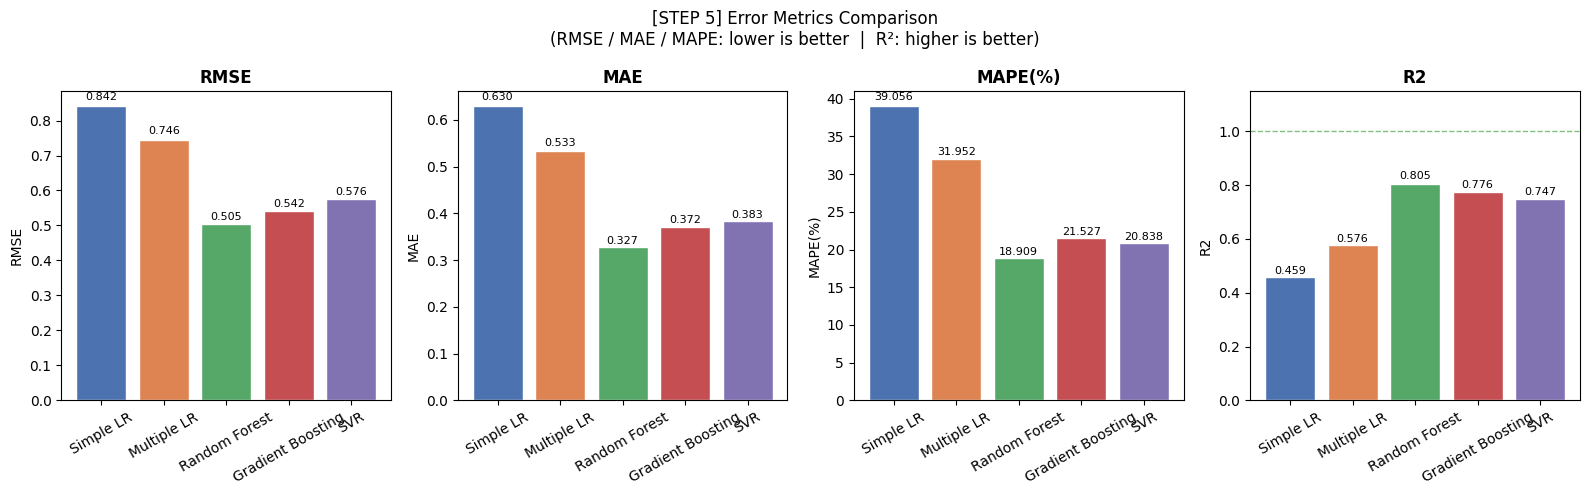

fig4 saved -- Error Metrics


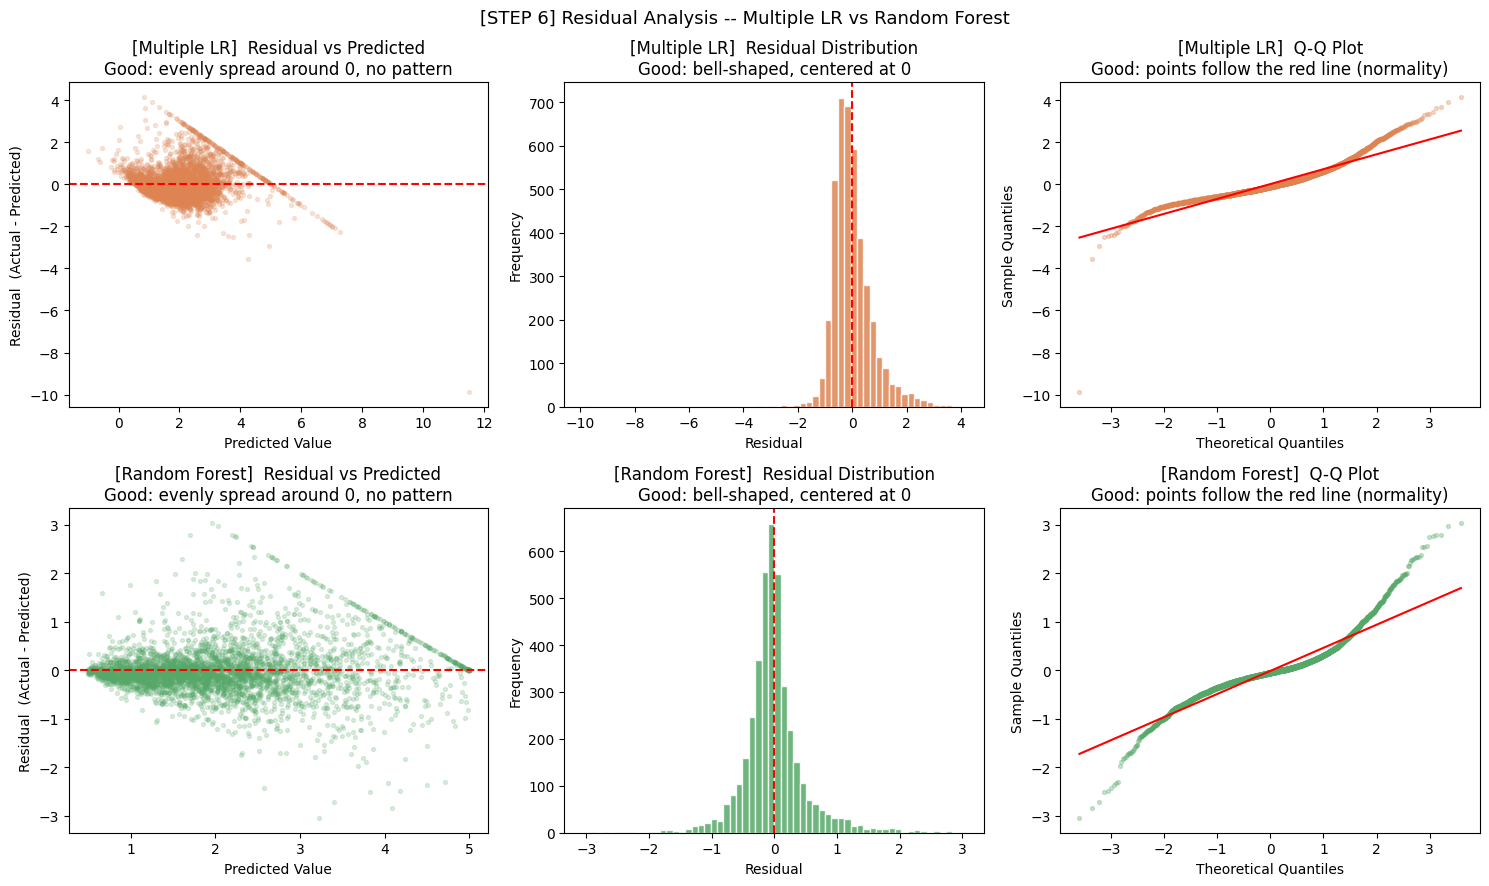

fig5 saved -- Residual Analysis


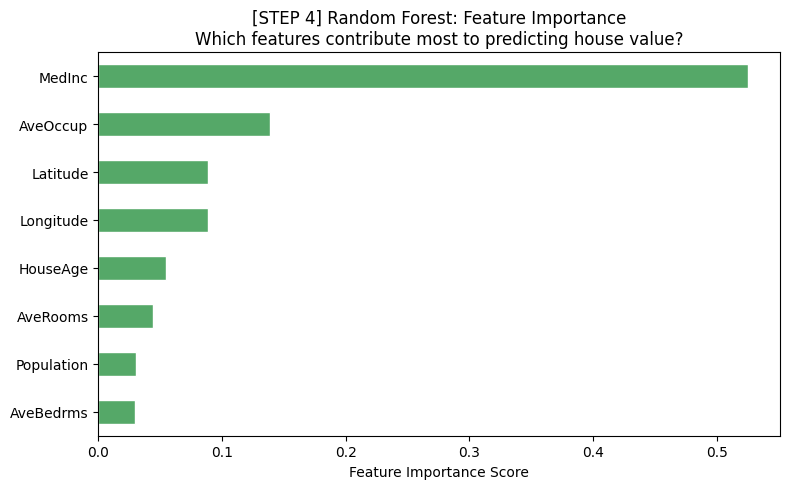

fig6 saved -- Feature Importance

All done!  6 figures saved.


In [17]:
# =============================================================
# STEP 6. Visualization  (6 figures)
# =============================================================
print("\n" + "=" * 60)
print("STEP 6. Visualization -- generating 6 figures")
print("=" * 60)

# ── Figure 1: Simple Linear Regression scatter plot ──────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_test['MedInc'], y_test,
           alpha=0.25, s=12, color='steelblue', label='Actual')
x_line = np.linspace(X_test['MedInc'].min(), X_test['MedInc'].max(), 300)
ax.plot(x_line, simple_lr.predict(x_line.reshape(-1, 1)),
        color='crimson', lw=2.5, label='Regression Line')
ax.set_xlabel('MedInc (Median Income)')
ax.set_ylabel('MedHouseVal (House Value, $100K)')
ax.set_title('[STEP 2] Simple Linear Regression: MedInc → House Value\n'
             f'R² = {r2_score(y_test, y_pred_simple):.4f}')
ax.legend()
plt.tight_layout()
plt.savefig('fig1_simple_regression.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig1 saved -- Simple Linear Regression")

# ── Figure 2: Multiple LR -- coefficient bar chart ───────────
fig, ax = plt.subplots(figsize=(8, 5))
cs = coef_df.sort_values('Coefficient')
bar_colors = ['#C44E52' if v > 0 else '#4C72B0' for v in cs['Coefficient']]
ax.barh(cs['Feature'], cs['Coefficient'], color=bar_colors, edgecolor='white')
ax.axvline(0, color='black', lw=1, linestyle='--')
ax.set_xlabel('Coefficient Value')
ax.set_title('[STEP 3] Multiple Linear Regression: Feature Coefficients\n'
             '(Red = positive impact / Blue = negative impact)')
plt.tight_layout()
plt.savefig('fig2_multi_lr_coef.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig2 saved -- Multiple LR Coefficients")

# ── Figure 3: Predicted vs Actual  (5 models + R2 bar) ───────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
flat = axes.flatten()

for i, (name, y_pred) in enumerate(y_preds.items()):
    ax = flat[i]
    ax.scatter(y_test, y_pred, alpha=0.2, s=8, color=C[i])
    lo = min(float(y_test.min()), float(y_pred.min()))
    hi = max(float(y_test.max()), float(y_pred.max()))
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1.5, label='Perfect Prediction')
    r2 = r2_score(y_test, y_pred)
    ax.set_title(f'{name}\nR² = {r2:.4f}')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.legend(fontsize=8)

# last panel: R2 comparison bar
ax = flat[5]
r2_vals = [r2_score(y_test, yp) for yp in y_preds.values()]
bars = ax.bar(list(y_preds.keys()), r2_vals, color=C, edgecolor='white')
ax.set_ylim(0, 1.15)
ax.set_ylabel('R² Score')
ax.set_title('R² Score Comparison\n(Higher is better)')
ax.tick_params(axis='x', rotation=20)
for bar, val in zip(bars, r2_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('[STEP 4~5] Predicted vs Actual by Model', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('fig3_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig3 saved -- Predicted vs Actual")

# ── Figure 4: Error metrics bar comparison ───────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, metric in zip(axes, ['RMSE', 'MAE', 'MAPE(%)', 'R2']):
    vals = result_df[metric]
    bars = ax.bar(vals.index, vals.values, color=C, edgecolor='white')
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.02,
                f'{val:.3f}', ha='center', fontsize=8)
    if metric == 'R2':
        ax.set_ylim(0, 1.15)
        ax.axhline(1.0, color='green', ls='--', lw=1, alpha=0.5)

plt.suptitle('[STEP 5] Error Metrics Comparison\n'
             '(RMSE / MAE / MAPE: lower is better  |  R²: higher is better)',
             fontsize=12)
plt.tight_layout()
plt.savefig('fig4_error_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig4 saved -- Error Metrics")

# ── Figure 5: Residual analysis  (Multiple LR vs Random Forest) ──
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
pairs = [
    ('Multiple LR',   y_preds['Multiple LR'],   C[1]),
    ('Random Forest', y_preds['Random Forest'],  C[2]),
]
for row, (name, y_pred, col) in enumerate(pairs):
    resid = y_test.values - y_pred

    # (a) Residual vs Predicted
    ax = axes[row][0]
    ax.scatter(y_pred, resid, alpha=0.2, s=8, color=col)
    ax.axhline(0, color='red', ls='--', lw=1.5)
    ax.set_xlabel('Predicted Value')
    ax.set_ylabel('Residual  (Actual - Predicted)')
    ax.set_title(f'[{name}]  Residual vs Predicted\n'
                 'Good: evenly spread around 0, no pattern')

    # (b) Residual histogram
    ax = axes[row][1]
    ax.hist(resid, bins=60, color=col, edgecolor='white', alpha=0.85)
    ax.axvline(0, color='red', ls='--', lw=1.5)
    ax.set_xlabel('Residual')
    ax.set_ylabel('Frequency')
    ax.set_title(f'[{name}]  Residual Distribution\n'
                 'Good: bell-shaped, centered at 0')

    # (c) Q-Q plot
    ax = axes[row][2]
    (osm, osr), (slope, intercept, r) = stats.probplot(resid, dist='norm')
    ax.scatter(osm, osr, alpha=0.3, s=8, color=col)
    x_qq = np.array([min(osm), max(osm)])
    ax.plot(x_qq, slope * x_qq + intercept, color='red', lw=1.5)
    ax.set_xlabel('Theoretical Quantiles')
    ax.set_ylabel('Sample Quantiles')
    ax.set_title(f'[{name}]  Q-Q Plot\n'
                 'Good: points follow the red line (normality)')

plt.suptitle('[STEP 6] Residual Analysis -- Multiple LR vs Random Forest',
             fontsize=13)
plt.tight_layout()
plt.savefig('fig5_residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig5 saved -- Residual Analysis")

# ── Figure 6: Random Forest feature importance ───────────────
importances = pd.Series(rf.feature_importances_,
                        index=housing.feature_names).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', ax=ax, color='#55A868', edgecolor='white')
ax.set_xlabel('Feature Importance Score')
ax.set_title('[STEP 4] Random Forest: Feature Importance\n'
             'Which features contribute most to predicting house value?')
plt.tight_layout()
plt.savefig('fig6_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig6 saved -- Feature Importance")

print("\n" + "=" * 60)
print("All done!  6 figures saved.")
print("=" * 60)